In [2]:

# Install BigQuery library
!pip install --upgrade google-cloud-bigquery

# Authenticate
from google.colab import auth
auth.authenticate_user()

# Import BigQuery client
from google.cloud import bigquery

# Setup BigQuery client
project_id = 'cool-benefit-456416-b0'
client = bigquery.Client(project=project_id)

# Define function to run query
def run_query(query):
    query_job = client.query(query)
    results = query_job.result()
    return results.to_dataframe()


### Van's Queries

In [3]:
# Query 1: Most popular name by decade
query_van_1 = """
WITH Name_Decade AS (
  SELECT
    name,
    SUM(number) AS total_births,
    CAST(year/10 AS INT64)*10 AS decade  # Changed to CAST to INT64
  FROM `bigquery-public-data.usa_names.usa_1910_current`
  GROUP BY name, decade
)
SELECT decade, name, total_births
FROM (
  SELECT *, ROW_NUMBER() OVER (PARTITION BY decade ORDER BY total_births DESC) as rn
  FROM Name_Decade
)
WHERE rn = 1
ORDER BY decade
"""
df_van_1 = run_query(query_van_1)
print("Van Query 1: Most Popular Name by Decade")
print(df_van_1)

Van Query 1: Most Popular Name by Decade
    decade     name  total_births
0     1910     Mary        161892
1     1920     Mary        680783
2     1930     Mary        638887
3     1940    James        650818
4     1950    James        867126
5     1960  Michael        872620
6     1970  Michael        784211
7     1980  Michael        684431
8     1990  Michael        600070
9     2000  Michael        331135
10    2010    Jacob        215500
11    2020     Liam        136044


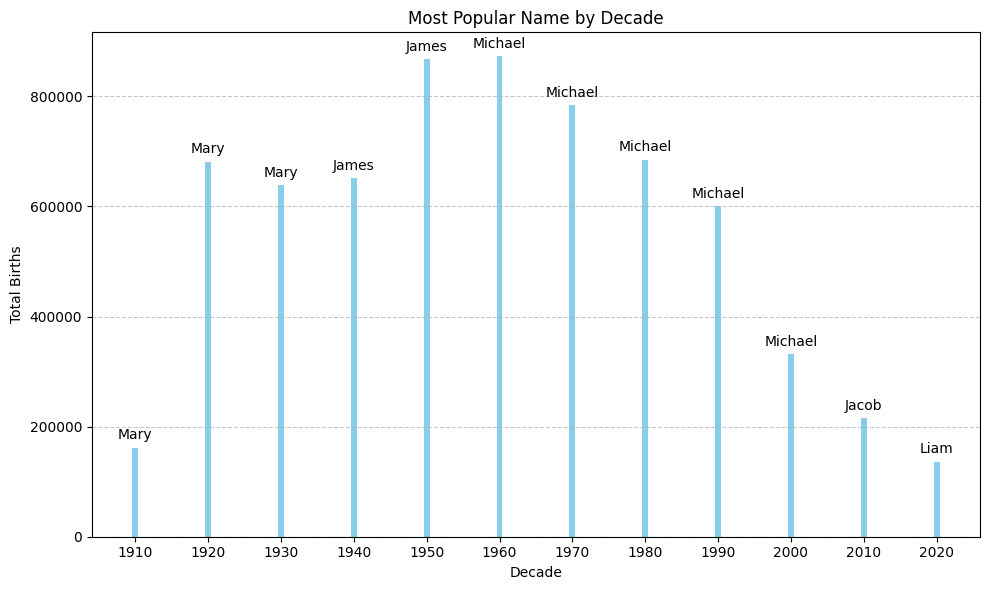

In [4]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.bar(df_van_1['decade'], df_van_1['total_births'], color='skyblue')
plt.xlabel('Decade')
plt.ylabel('Total Births')
plt.title('Most Popular Name by Decade')
plt.xticks(df_van_1['decade'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, name in enumerate(df_van_1['name']):
    plt.text(df_van_1['decade'][i], df_van_1['total_births'][i] + 10000, name, ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [8]:
# Query 2: Gender-neutral names
query_van_2 = """
WITH Name_Gender AS (
  SELECT name, gender, SUM(number) AS total_births
  FROM `bigquery-public-data.usa_names.usa_1910_current`
  GROUP BY name, gender
),
Name_Totals AS (
  SELECT name,
       SUM(CASE WHEN gender='M' THEN total_births ELSE 0 END) as male_count,
       SUM(CASE WHEN gender='F' THEN total_births ELSE 0 END) as female_count,
       SUM(total_births) AS total_count  -- Calculate total births for each name
  FROM Name_Gender
  GROUP BY name
  HAVING ABS(SUM(CASE WHEN gender='M' THEN total_births ELSE 0 END) - SUM(CASE WHEN gender='F' THEN total_births ELSE 0 END)) < 1000
)
SELECT name, male_count, female_count
FROM Name_Totals
ORDER BY total_count DESC  -- Sort by total births in descending order
LIMIT 20  -- Limit to the top 20 names
"""
df_van_2 = run_query(query_van_2)
print("Van Query 2: Gender Neutral Names (Top 20)")
print(df_van_2)

Van Query 2: Gender Neutral Names (Top 20)
       name  male_count  female_count
0     Kerry       46363         45622
1   Justice       16796         16561
2      Kris       10979         11020
3    Stevie        9500          9711
4   Unknown        7208          7501
5      Baby        4664          4166
6    Infant        3971          3684
7     Arden        3563          3784
8    Landry        3569          3767
9    Palmer        3375          3680
10    Briar        3243          3157
11     Yael        3050          2549
12   Austyn        3095          2425
13     Jael        1875          2193
14    Maxie        2135          1827
15   Camdyn        2350          1356
16  Lorenza        1900          1466
17  Claudie        1478          1882
18    Ryley        1849          1422
19     Ocie        1087          1938


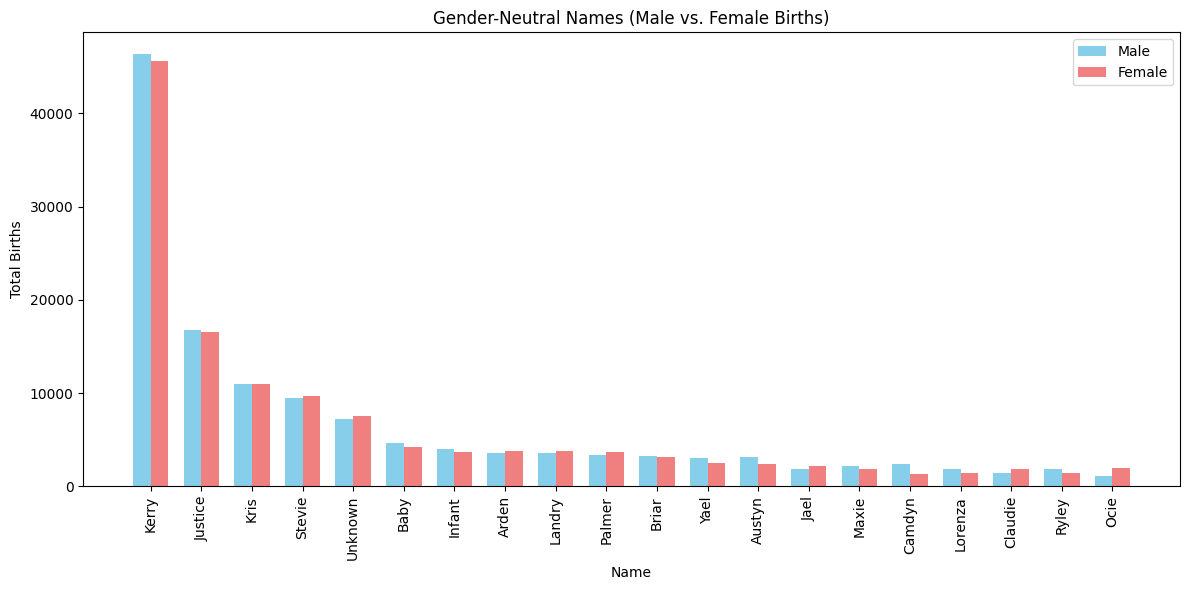

In [9]:
import matplotlib.pyplot as plt
import numpy as np

names = df_van_2['name']
male_counts = df_van_2['male_count']
female_counts = df_van_2['female_count']

bar_width = 0.35
x_pos = np.arange(len(names))

plt.figure(figsize=(12, 6))
plt.bar(x_pos, male_counts, bar_width, label='Male', color='skyblue')
plt.bar(x_pos + bar_width, female_counts, bar_width, label='Female', color='lightcoral')

plt.xticks(x_pos + bar_width / 2, names, rotation=90)
plt.xlabel('Name')
plt.ylabel('Total Births')
plt.title('Gender-Neutral Names (Male vs. Female Births)')
plt.legend()
plt.tight_layout()
plt.show()

### Stephen's Queries

In [11]:

# Query 1: States with most unique names
query_stephen_1 = """
SELECT state, COUNT(DISTINCT name) AS unique_names
FROM `bigquery-public-data.usa_names.usa_1910_current`
GROUP BY state
ORDER BY unique_names DESC
LIMIT 10
"""
df_stephen_1 = run_query(query_stephen_1)
print("Stephen Query 1: States with Most Unique Names")
print(df_stephen_1)


Stephen Query 1: States with Most Unique Names
  state  unique_names
0    CA         20239
1    TX         18238
2    NY         14997
3    FL         11869
4    IL         11493
5    GA         10284
6    OH          9844
7    PA          9582
8    NC          9345
9    MI          9178


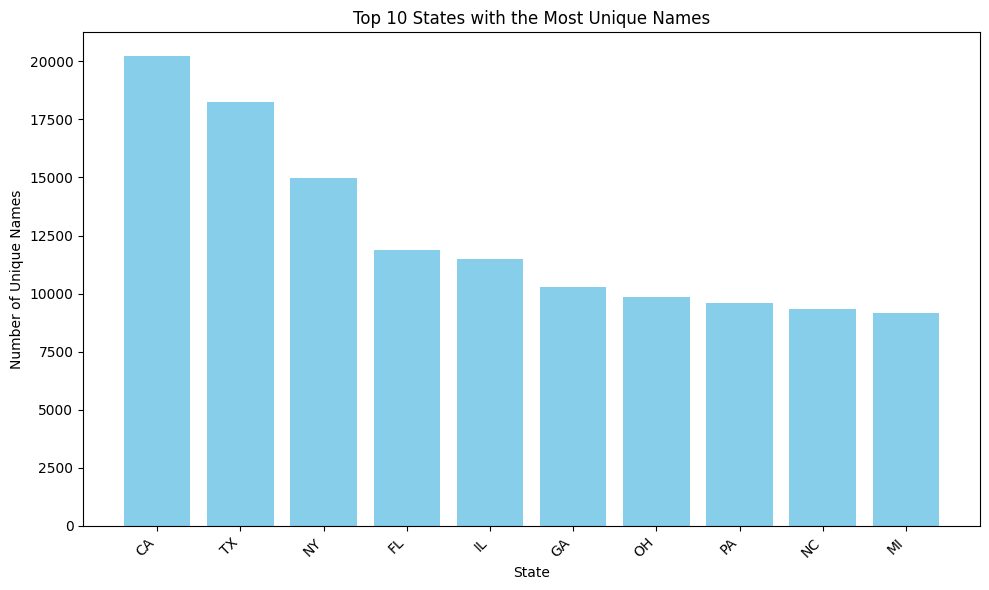

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(df_stephen_1['state'], df_stephen_1['unique_names'], color='skyblue')
plt.xlabel('State')
plt.ylabel('Number of Unique Names')
plt.title('Top 10 States with the Most Unique Names')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:

# Query 2: Fastest rising names after 1990
query_stephen_2 = """
WITH Name_90s AS (
  SELECT name, SUM(number) AS total_90s
  FROM `bigquery-public-data.usa_names.usa_1910_current`
  WHERE year BETWEEN 1990 AND 1999
  GROUP BY name
),
Name_2000s AS (
  SELECT name, SUM(number) AS total_2000s
  FROM `bigquery-public-data.usa_names.usa_1910_current`
  WHERE year BETWEEN 2000 AND 2009
  GROUP BY name
)
SELECT n2.name, n1.total_90s, n2.total_2000s, (n2.total_2000s - n1.total_90s) AS increase
FROM Name_90s n1
JOIN Name_2000s n2 ON n1.name = n2.name
ORDER BY increase DESC
LIMIT 10
"""
df_stephen_2 = run_query(query_stephen_2)
print("Stephen Query 2: Fastest Rising Names after 1990")
print(df_stephen_2)


Stephen Query 2: Fastest Rising Names after 1990
       name  total_90s  total_2000s  increase
0     Ethan      66914       201931    135017
1  Isabella      18484       149591    131107
2      Emma      58213       181425    123212
3       Ava       3691       104534    100843
4   Madison      93465       193665    100200
5    Jayden       3506       102417     98911
6    Sophia      24296       119246     94950
7      Noah      56232       143677     87445
8     Aiden       1268        84046     82778
9    Olivia      75902       156104     80202


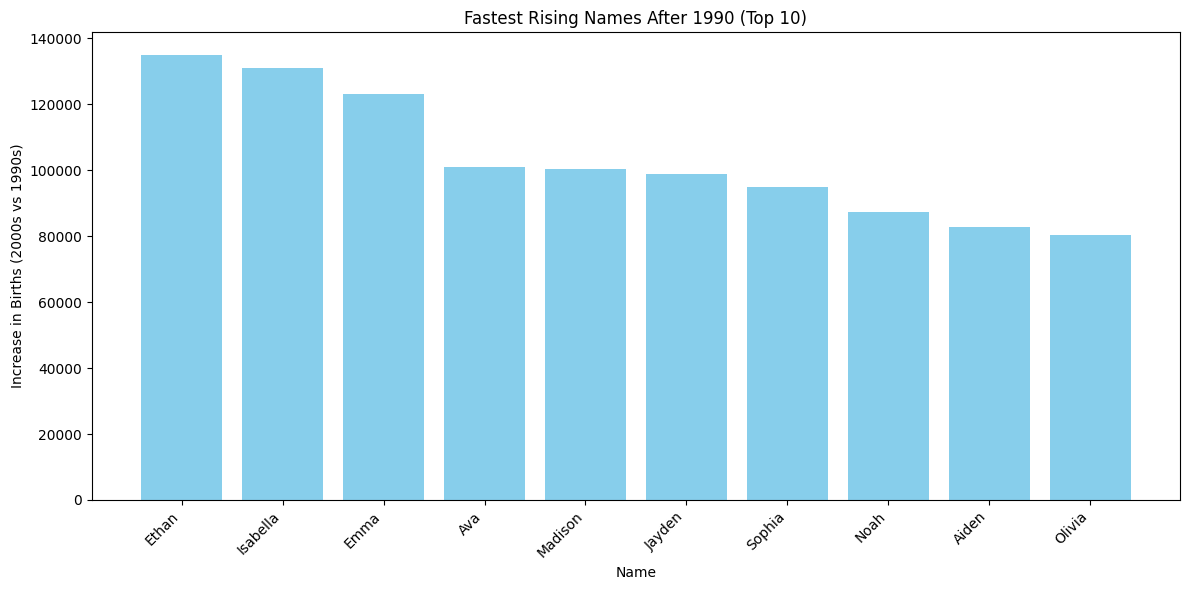

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(df_stephen_2['name'], df_stephen_2['increase'], color='skyblue')
plt.xlabel('Name')
plt.ylabel('Increase in Births (2000s vs 1990s)')
plt.title('Fastest Rising Names After 1990 (Top 10)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Andy's Queries

In [16]:

# Query 1: Celebrity influence - 'Kobe'
query_andy_1 = """
SELECT year, SUM(number) AS total_births
FROM `bigquery-public-data.usa_names.usa_1910_current`
WHERE name = 'Kobe'
GROUP BY year
ORDER BY year
"""
df_andy_1 = run_query(query_andy_1)
print("Andy Query 1: Celebrity Influence - 'Kobe' Name Trend")
print(df_andy_1)


Andy Query 1: Celebrity Influence - 'Kobe' Name Trend
    year  total_births
0   1996            37
1   1997           304
2   1998          1093
3   1999           829
4   2000          1425
5   2001          1538
6   2002          1383
7   2003          1200
8   2004           594
9   2005           412
10  2006           429
11  2007           535
12  2008           706
13  2009           650
14  2010           622
15  2011           510
16  2012           512
17  2013           519
18  2014           484
19  2015           422
20  2016           550
21  2017           509
22  2018           439
23  2019           473
24  2020          1493
25  2021          1101


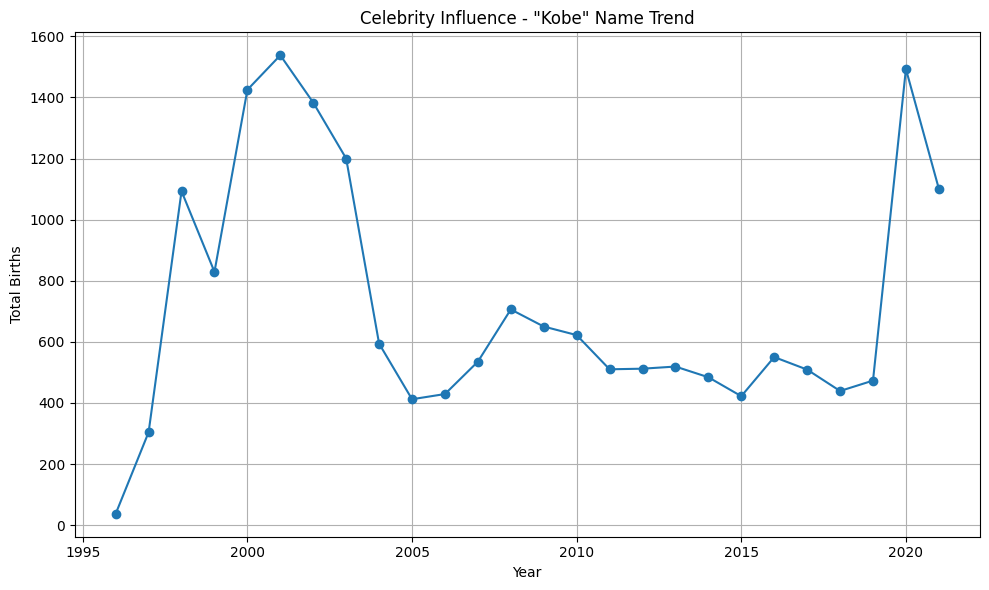

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df_andy_1['year'], df_andy_1['total_births'], marker='o', linestyle='-')
plt.xlabel('Year')
plt.ylabel('Total Births')
plt.title('Celebrity Influence - "Kobe" Name Trend')
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
# Query 2: Stable names across decades
query_andy_2 = """
WITH Name_Year AS (
  SELECT name, year, SUM(number) AS total_births
  FROM `bigquery-public-data.usa_names.usa_1910_current`
  GROUP BY name, year
),

Name_Decade AS (
  SELECT
    name,
    CAST(year / 10 AS INT64) * 10 AS decade,
    SUM(total_births) AS total_births
  FROM Name_Year
  GROUP BY name, decade
),

Name_Decade_Stats AS (
  SELECT
    name,
    AVG(total_births) AS avg_births,
    STDDEV(total_births) AS stddev_births,
    COUNT(*) AS decades_count
  FROM Name_Decade
  GROUP BY name
  HAVING avg_births > 100 AND decades_count >= 2
)

SELECT
  name,
  avg_births AS overall_avg_births,
  stddev_births AS avg_stddev_births
FROM Name_Decade_Stats
ORDER BY avg_stddev_births ASC
LIMIT 10

"""
df_andy_2 = run_query(query_andy_2)
print("Andy Query 2: Most Stable Names Across Decades")
print(df_andy_2)

Andy Query 2: Most Stable Names Across Decades
      name  overall_avg_births  avg_stddev_births
0   Jarrad               235.0           0.000000
1   Emalyn               347.0           0.000000
2      Ily               132.5           0.707107
3   Atreyu               513.5           0.707107
4    Darsh               144.0           1.414214
5   Aisley               105.0           1.414214
6    Jadin               347.0           1.414214
7  Analiah               191.0           1.414214
8     Bane               103.5           2.121320
9   Mannat               114.5           2.121320


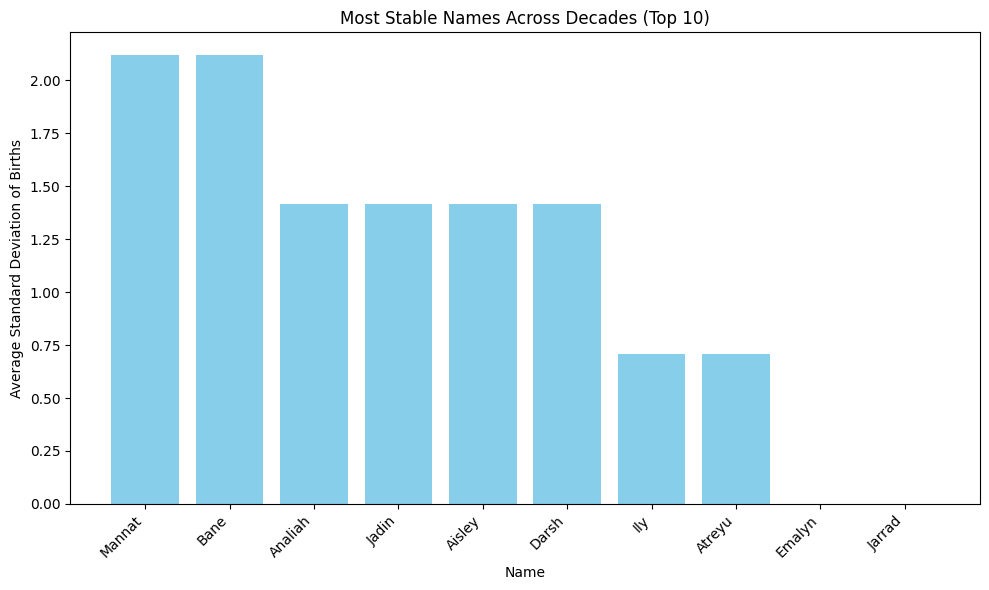

In [24]:
import matplotlib.pyplot as plt

# Sort df_andy_2 by avg_stddev_births in descending order
df_andy_2_sorted = df_andy_2.sort_values(by=['avg_stddev_births'], ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(df_andy_2_sorted['name'], df_andy_2_sorted['avg_stddev_births'], color='skyblue')
plt.xlabel('Name')
plt.ylabel('Average Standard Deviation of Births')
plt.title('Most Stable Names Across Decades (Top 10)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()